# Attack Candidate Pool Evaluation

Purpose: Evaluate and inspect full-state adversarial candidate pools with the scored Monte Carlo simulator.

Role in project: canonical analysis notebook

Inputs:
- VAE candidate JSONL pool
- convoy profile and simulator configuration

Outputs:
- ranked candidate artifacts under `results/notebook-results/attack_candidate_pool_eval/`

Expected runtime: medium to long, depending on candidate count and trial budget.

Notes:
- Use the run/load switches in the configuration cell to avoid rerunning expensive evaluations.


## Imports And Repo Setup


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve repo root when this notebook is launched from either repo root or notebooks/

from convoy_sim.attack_profiles import AttackProfile
from convoy_sim.profile_generation_viz import (
    FIXED_X_LIMITS,
    apply_limits,
    combined_limits,
    plot_attack_example,
    simple_ship_polygons,
    style_ax,
)
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool
from experiments.evaluate_attack_candidate_pool import load_candidate_records
from scenarios.convoy_profiles import get_convoy_layout_profile

PROJECT_ROOT


PosixPath('/Users/matthewplambeck/Desktop/Convoy Layout Project')

## Configuration


In [2]:
NOTEBOOK_NAME = "attack_candidate_pool_eval"

# Input candidate pool.
CANDIDATE_PATH = Path("results/notebook-results/vae_candidate_pool/curated_v4_hit_candidates.jsonl")
CONVOY_PROFILE = "convoy_layout_1"

# Evaluation output.
RUN_EVALUATION = True
EXISTING_RUN_DIR = Path("results/runs/candidate_pool_eval/SET_ME_IF_RUN_EVALUATION_FALSE")
OUTPUT_ROOT = PROJECT_ROOT / "results" / "notebook-results" / "attack_candidate_pool_eval" / "runs"
RUN_NAME = "vae_full_state_baseline_notebook"

# Keep these small for initial notebook iteration; increase after the cells behave as expected.
MAX_PROFILES = 100  # None evaluates the full candidate pool
TOP_K = 25
SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
T_MAX = 400.0
MAX_HITS_PER_TORPEDO = 1
OBJECTIVE_PRESET = "balanced_default"  # set to None for expected-hits ranking

# Optional runtime realism. These defaults mirror the baseline/RL configs.
SHIP_MOVEMENT_REALISM = {
    "position_jitter_std_m": 8.0,
    "heading_jitter_std_rad": 0.015,
    "deviation_offset_cap_m": 12.0,
    "enable_slot_swaps": False,
    "max_swap_fraction": 0.0,
    "freighter_scale": 1.0,
    "tanker_scale": 0.9,
    "escort_scale": 0.6,
    "decoy_scale": 1.1,
}

NOISE_CFG = {}
ENVIRONMENT_CFG = {
    "time_of_day": "night",
    "visibility_m": 3500.0,
    "sea_state": 4,
    "detection_risk_scale": 1.0,
}


## Evaluate Or Load Run

In [3]:
objective_cfg = {} if OBJECTIVE_PRESET in {None, "", "none", "None"} else {"preset": str(OBJECTIVE_PRESET)}

if RUN_EVALUATION:
    RUN_DIR = evaluate_candidate_pool(
        candidate_path=PROJECT_ROOT / CANDIDATE_PATH,
        project_root=PROJECT_ROOT,
        output_root=OUTPUT_ROOT,
        run_name=RUN_NAME,
        convoy_profile=CONVOY_PROFILE,
        max_profiles=MAX_PROFILES,
        top_k=int(TOP_K),
        seeds=SEEDS,
        n_trials_per_seed=int(N_TRIALS_PER_SEED),
        t_max=float(T_MAX),
        max_hits_per_torpedo=MAX_HITS_PER_TORPEDO,
        objective_cfg=objective_cfg,
        noise_cfg=NOISE_CFG,
        environment_cfg=ENVIRONMENT_CFG,
        ship_movement_realism=SHIP_MOVEMENT_REALISM,
    )
else:
    RUN_DIR = PROJECT_ROOT / EXISTING_RUN_DIR

RUN_DIR


FileNotFoundError: [Errno 2] No such file or directory: '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/vae_candidate_pool/curated_v4_hit_candidates.jsonl'

## Load Artifacts

In [ ]:
metrics_summary = json.loads((RUN_DIR / "metrics_summary.json").read_text(encoding="utf-8"))
run_manifest = json.loads((RUN_DIR / "run_manifest.json").read_text(encoding="utf-8"))
top_payload = json.loads((RUN_DIR / "top_candidates.json").read_text(encoding="utf-8"))
ranked_df = pd.read_csv(RUN_DIR / "ranked_candidates.csv")
candidate_records = load_candidate_records(PROJECT_ROOT / CANDIDATE_PATH)
candidate_by_id = {str(record["profile"]["profile_id"]): record for record in candidate_records}

print(f"run_dir: {RUN_DIR}")
print(f"ranked candidates: {len(ranked_df):,}")
print(f"top candidates: {len(top_payload['candidates']):,}")


run_dir: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook
ranked candidates: 100
top candidates: 25


## Summary

In [ ]:
summary_view = {
    "selection": metrics_summary.get("selection"),
    "candidate_pool": metrics_summary.get("candidate_pool"),
    "top_k": metrics_summary.get("top_k"),
    "best_candidate": metrics_summary.get("best_candidate"),
}
summary_view


{'selection': {'method': 'full_state_attacker_rank',
  'score': 'expected_loss',
  'higher_is_better_for_attacker': True,
  'top_k': 25},
 'candidate_pool': {'profiles': 100,
  'samples': 3000,
  'expected_hits': 2.9223333333333334,
  'CVaR_90': 3.286696811473127,
  'VaR_90': 4.0,
  'p_hit_ge_1': 0.9786666666666668,
  'value_lost': 1.7346166666666667,
  'expected_unique_ships_hit': 1.6926666666666665,
  'expected_repeat_hits': 1.2296666666666667,
  'expected_loss': 3.673216666666667,
  'CVaR_90_loss': 4.145982108397154},
 'top_k': {'profiles': 25,
  'samples': 750,
  'expected_hits': 3.2386666666666675,
  'CVaR_90': 3.645543859649123,
  'VaR_90': 3.986666666666667,
  'p_hit_ge_1': 1.0,
  'value_lost': 2.5708666666666664,
  'expected_unique_ships_hit': 2.474666666666667,
  'expected_repeat_hits': 0.764,
  'expected_loss': 5.198333333333334,
  'CVaR_90_loss': 5.98723956043956},
 'best_candidate': {'model_name': 'vae_candidate_pool_full_state',
  'profile_id': 'VAE000046',
  'samples': 30

## Ranked Candidates

In [ ]:
display_columns = [
    "rank",
    "profile_id",
    "attacker_score",
    "expected_hits",
    "expected_unique_ships_hit",
    "expected_repeat_hits",
    "expected_loss",
    "CVaR_90_loss",
    "p_hit_ge_1",
    "spawn_region",
    "approach_side",
    "source_n_hits",
    "source_unique_ships_hit",
    "source_clearance_m",
    "source_closest_any_ship_distance_m",
]
ranked_df[display_columns].head(int(TOP_K))


,rank,profile_id,attacker_score,expected_hits,expected_unique_ships_hit,expected_repeat_hits,expected_loss,CVaR_90_loss,p_hit_ge_1,spawn_region,approach_side,source_n_hits,source_unique_ships_hit,source_clearance_m,source_closest_any_ship_distance_m
0,1,VAE000046,6.426667,4.000000,3.066667,0.933333,6.426667,8.150000,1.0,ahead_vae,ahead,4,3,329.943115,8.284650
1,2,VAE000105,6.396667,4.000000,3.000000,1.000000,6.396667,6.400000,1.0,astern_vae,astern,4,3,1513.245772,9.690828
2,3,VAE000090,6.216667,3.033333,3.033333,0.000000,6.216667,6.216667,1.0,inside_convoy_envelope,inside,3,3,506.163335,12.723701
3,4,VAE000032,6.166667,3.333333,3.000000,0.333333,6.166667,6.300000,1.0,inside_convoy_envelope,inside,4,3,584.714966,26.905315
4,5,VAE000098,6.081667,3.833333,2.900000,0.933333,6.081667,6.300000,1.0,starboard_vae,starboard,4,3,1225.426698,17.172886
5,6,VAE000060,5.860000,3.733333,2.733333,1.000000,5.860000,6.400000,1.0,port_vae,port,4,3,1629.809535,22.480352
6,7,VAE000062,5.848333,2.866667,2.866667,0.000000,5.848333,6.150000,1.0,ahead_vae,ahead,3,3,1837.519504,27.834424
7,8,VAE000117,5.820000,3.000000,2.900000,0.100000,5.820000,6.000000,1.0,starboard_vae,starboard,3,3,1571.209138,20.586009
8,9,VAE000070,5.416667,2.666667,2.666667,0.000000,5.416667,6.100000,1.0,starboard_vae,starboard,3,3,2322.585258,18.048282
9,10,VAE000114,5.273333,3.966667,2.433333,1.533333,5.273333,6.300000,1.0,astern_vae,astern,4,3,1384.722385,7.952475


## Region And Score Diagnostics

In [ ]:
region_summary = (
    ranked_df.groupby("spawn_region", dropna=False)
    .agg(
        profiles=("profile_id", "count"),
        mean_attacker_score=("attacker_score", "mean"),
        max_attacker_score=("attacker_score", "max"),
        mean_expected_hits=("expected_hits", "mean"),
        mean_expected_loss=("expected_loss", "mean"),
    )
    .sort_values(["max_attacker_score", "mean_attacker_score"], ascending=False)
)
region_summary


,profiles,mean_attacker_score,max_attacker_score,mean_expected_hits,mean_expected_loss
spawn_region,,,,,
ahead_vae,26,3.878397,6.426667,3.035897,3.878397
astern_vae,21,3.910714,6.396667,2.688889,3.910714
inside_convoy_envelope,19,3.178596,6.216667,2.959649,3.178596
starboard_vae,14,3.889643,6.081667,2.816667,3.889643
port_vae,20,3.475500,5.860000,3.058333,3.475500


## Plots

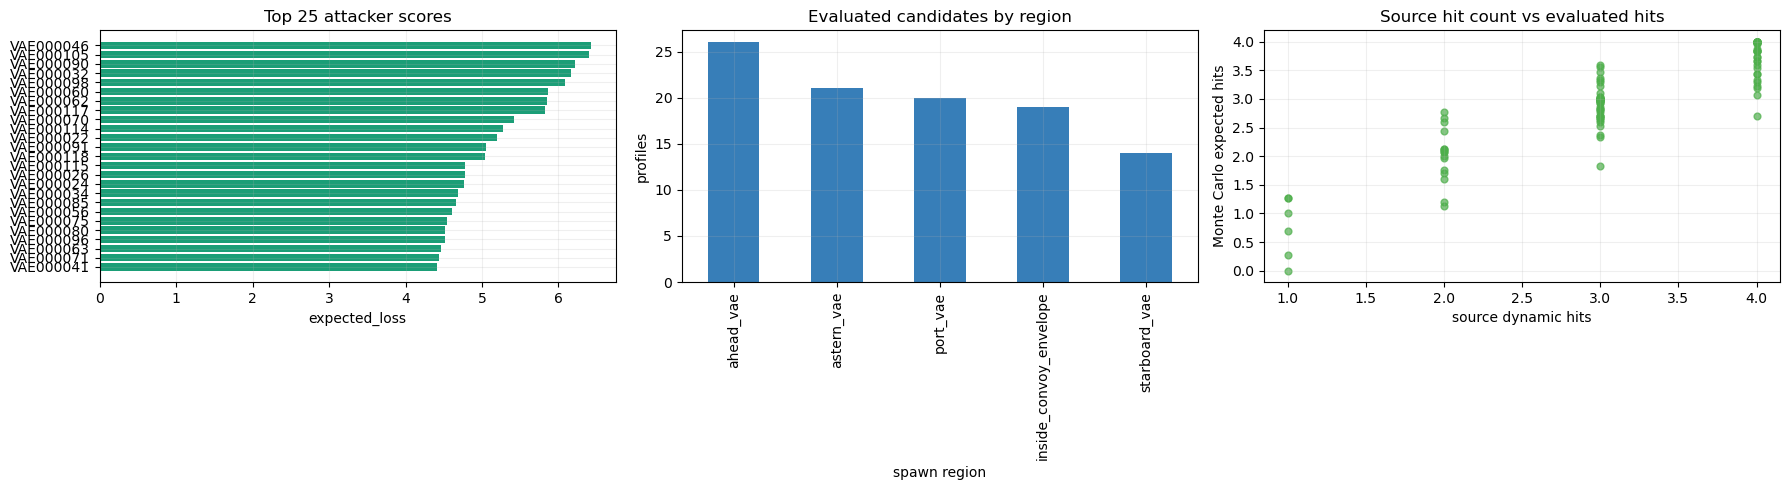

In [ ]:
top_df = ranked_df.head(int(TOP_K)).copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="white")

axes[0].barh(top_df["profile_id"].astype(str), top_df["attacker_score"], color="#1b9e77")
axes[0].invert_yaxis()
axes[0].set_title(f"Top {TOP_K} attacker scores")
axes[0].set_xlabel(metrics_summary["selection"]["score"])

ranked_df["spawn_region"].value_counts().plot.bar(ax=axes[1], color="#377eb8")
axes[1].set_title("Evaluated candidates by region")
axes[1].set_xlabel("spawn region")
axes[1].set_ylabel("profiles")

axes[2].scatter(ranked_df["source_n_hits"], ranked_df["expected_hits"], s=24, alpha=0.7, color="#4daf4a")
axes[2].set_title("Source hit count vs evaluated hits")
axes[2].set_xlabel("source dynamic hits")
axes[2].set_ylabel("Monte Carlo expected hits")

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Spawn Plan View

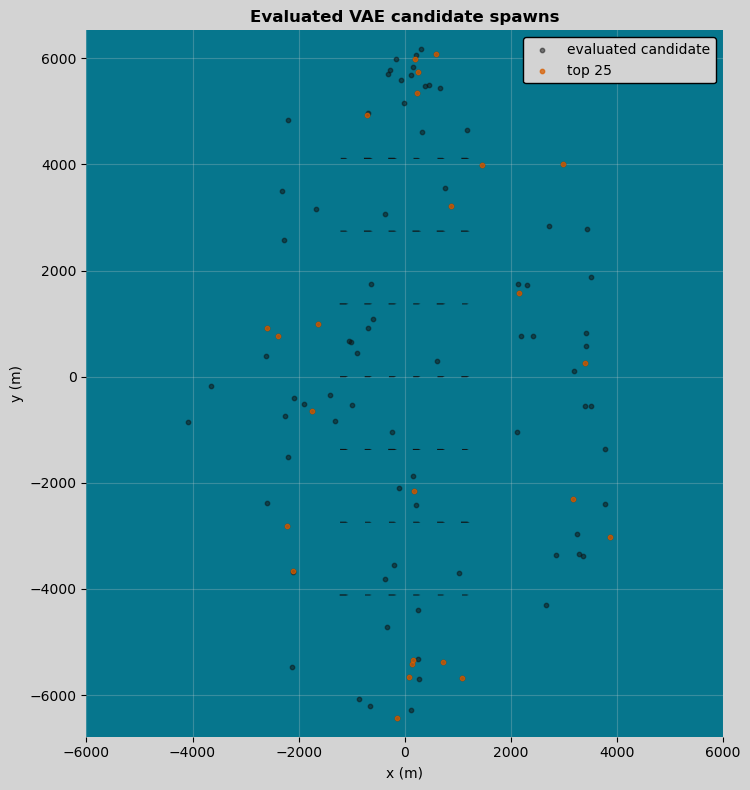

In [ ]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
all_xy = ranked_df[["source_clearance_m"]].copy()  # keeps pandas imported in this cell for lightweight validation
points = []
for profile_id in ranked_df["profile_id"].astype(str).tolist():
    record = candidate_by_id.get(profile_id)
    if record is None:
        continue
    points.append(record["profile"]["u_pos"])
points_xy = np.asarray(points, dtype=float) if points else np.empty((0, 2), dtype=float)
limits = combined_limits(ships, extra_points=points_xy if len(points_xy) else None, pad=350.0)

fig, ax = plt.subplots(figsize=(10, 8), facecolor="lightgrey")
style_ax(ax, "Evaluated VAE candidate spawns")
simple_ship_polygons(ax, ships)
if len(points_xy):
    ax.scatter(points_xy[:, 0], points_xy[:, 1], c="#111111", s=10, alpha=0.5, label="evaluated candidate", zorder=2)
    top_points = []
    for profile_id in ranked_df.head(int(TOP_K))["profile_id"].astype(str).tolist():
        record = candidate_by_id.get(profile_id)
        if record is not None:
            top_points.append(record["profile"]["u_pos"])
    if top_points:
        top_xy = np.asarray(top_points, dtype=float)
        ax.scatter(top_xy[:, 0], top_xy[:, 1], c="#d95f02", s=10, alpha=0.75, label=f"top {TOP_K}", zorder=4)
ax.legend(frameon=True, facecolor="lightgrey", edgecolor="black", framealpha=1.0)
apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.tight_layout()
plt.show()


## Top Candidate Attack Examples

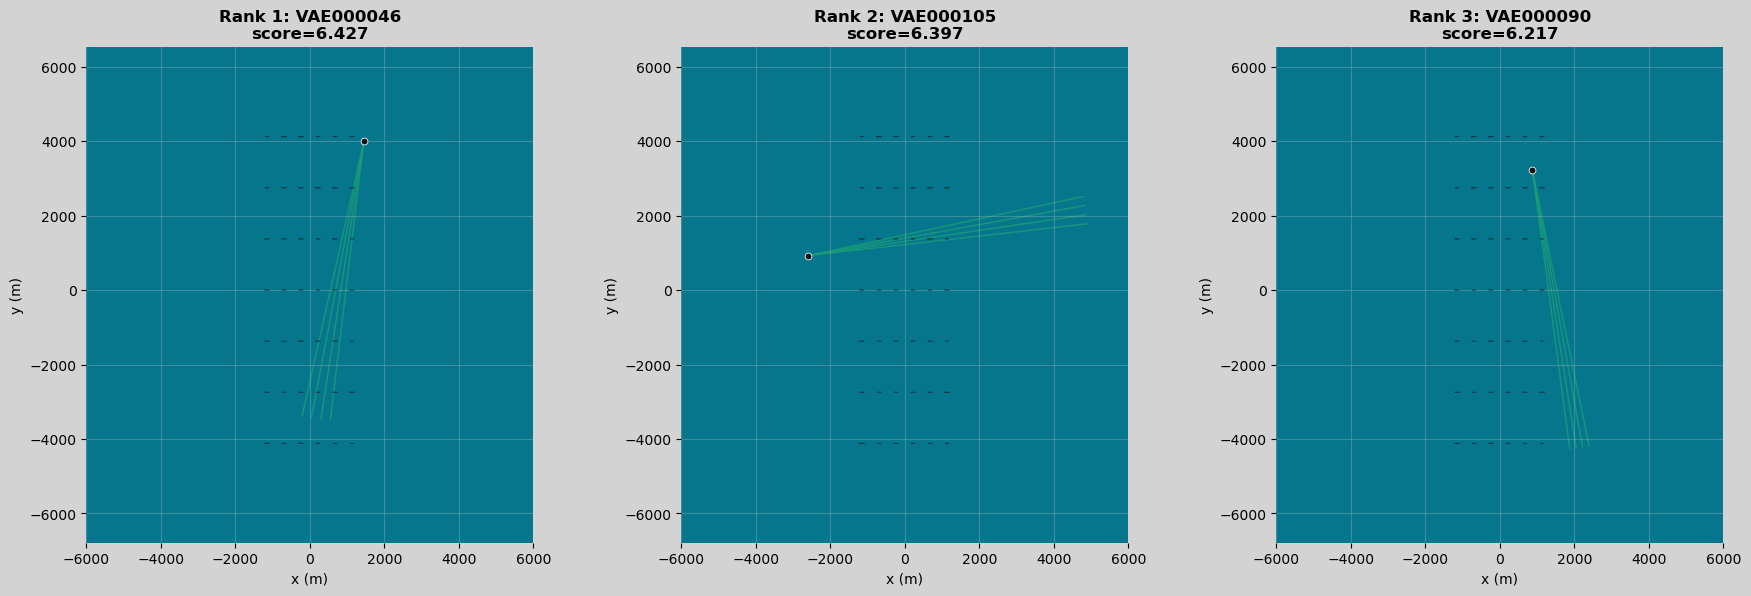

In [ ]:
example_count = min(3, len(ranked_df))
example_ids = ranked_df.head(example_count)["profile_id"].astype(str).tolist()
fig, axes = plt.subplots(1, example_count, figsize=(6 * example_count, 6), facecolor="lightgrey")
if example_count == 1:
    axes = [axes]
for ax, profile_id in zip(axes, example_ids):
    record = candidate_by_id[profile_id]
    profile = AttackProfile.from_dict(record["profile"])
    rank = int(ranked_df.loc[ranked_df["profile_id"].astype(str) == profile_id, "rank"].iloc[0])
    score = float(ranked_df.loc[ranked_df["profile_id"].astype(str) == profile_id, "attacker_score"].iloc[0])
    plot_attack_example(
        ax,
        ships,
        profile,
        title=f"Rank {rank}: {profile_id}\nscore={score:.3f}",
        accepted=True,
        seed=int(SEEDS[0]),
        limits=limits,
    )
    apply_limits(ax, limits, fixed_x_limits=FIXED_X_LIMITS)
plt.tight_layout()
plt.show()


## Artifact Paths

In [ ]:
{
    "run_dir": str(RUN_DIR),
    "ranked_candidates_csv": str(RUN_DIR / "ranked_candidates.csv"),
    "top_candidates_json": str(RUN_DIR / "top_candidates.json"),
    "metrics_summary_json": str(RUN_DIR / "metrics_summary.json"),
    "run_manifest_json": str(RUN_DIR / "run_manifest.json"),
}


{'run_dir': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook',
 'ranked_candidates_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook/ranked_candidates.csv',
 'top_candidates_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook/top_candidates.json',
 'metrics_summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook/metrics_summary.json',
 'run_manifest_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260511_185027_vae_full_state_baseline_notebook/run_manifest.json'}